**MOST RECENT VERSION OF THIS FILE, CHECK GITHUB FOR PROGRESS!!**

In [4]:
import symlib

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colormaps
import matplotlib.colors as mcolors

import numpy as np
import os

import scipy
from scipy import stats

1 SymphonyLMC
Loading host 38 in suite SymphonyLMC
2 SymphonyMilkyWay
Loading host 44 in suite SymphonyMilkyWay
3 MWest
Loading host 19 in suite MWest
4 SymphonyGroup
Loading host 48 in suite SymphonyGroup
5 SymphonyLCluster
Loading host 32 in suite SymphonyLCluster
6 SymphonyCluster
Loading host 0 in suite SymphonyCluster

C:\Users\steph\AppData\Local\Temp\ipykernel_17144\3035752548.py:54: RuntimeWarning: Mean of empty slice
  avg_masses = np.nanmean(vstacked_masses, axis = 0)
C:\Users\steph\miniconda3\envs\dm-analysis-env\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\steph\miniconda3\envs\dm-analysis-env\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


Loading host 80 in suite SymphonyCluster


C:\Users\steph\AppData\Local\Temp\ipykernel_17144\3035752548.py:54: RuntimeWarning: Mean of empty slice
  avg_masses = np.nanmean(vstacked_masses, axis = 0)
C:\Users\steph\miniconda3\envs\dm-analysis-env\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\steph\miniconda3\envs\dm-analysis-env\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


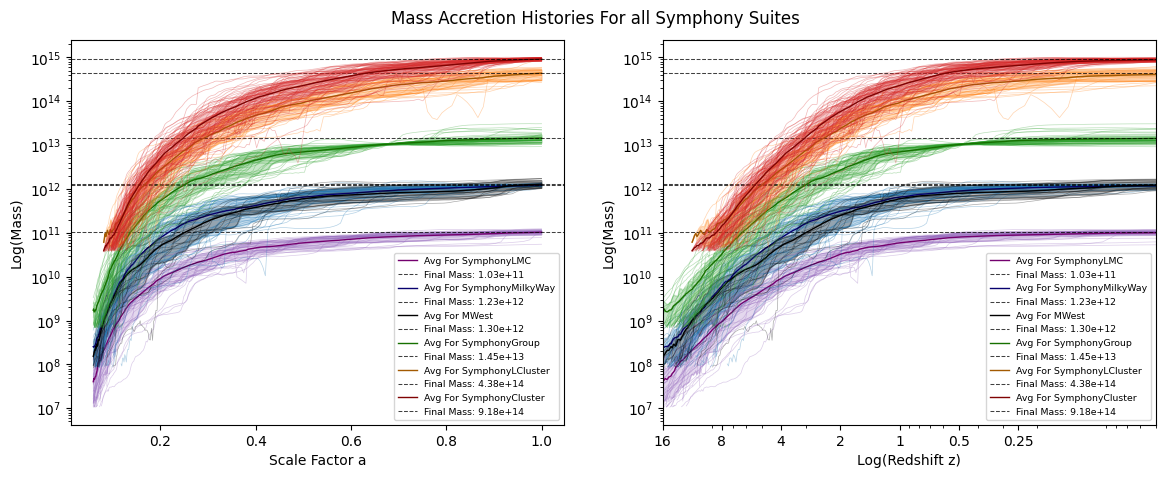

In [111]:
base_dir = "C:/Users/steph/Symphony"
suite_list = ["SymphonyLMC", "SymphonyMilkyWay", "MWest", "SymphonyGroup", "SymphonyLCluster", "SymphonyCluster"]
colors = ["tab:purple", "tab:blue", "black", "tab:green", "tab:orange", "tab:red"]
avg_colors = [(102/225, 0/255, 110/255), (7/255, 0/255, 110/255), (0, 0, 0),
              (22/255, 112/255, 0/255), (163/255, 90/255, 2/255), (128/255, 3/255, 3/255)]

fig, ax = plt.subplots(ncols = 2, figsize = (14, 5))

for index, suite in enumerate(suite_list):
    print(index + 1, suite)
    
    n_hosts = symlib.n_hosts(suite)
    
    masses_suite = []
    scale_factors_suite = []

    for i_host in range(n_hosts):
        print(f"Loading host {i_host} in suite {suite}", end = "\r", flush = True)
        sim_dir = symlib.get_host_directory(base_dir, suite, i_host)
        h, hist = symlib.read_subhalos(sim_dir)
        host_scale_factors = symlib.scale_factors(sim_dir)
        host_redshifts = (1 / host_scale_factors) - 1
        host_z_mask = host_redshifts <= 16
        if suite == "MWest":
            host_z_mask = host_z_mask & (host_scale_factors <= 1)   ## cutting MWest off at z = 0 (a = 1)

        params = symlib.simulation_parameters(sim_dir)
        particle_mass = params["mp"]
  
        host_mass = np.array(h["mvir"][0])
        host_ok = np.array(h["ok"][0])
        mass_cut = 300 * particle_mass
        
        host_mass_masked = np.where((host_mass < mass_cut) | ~host_ok, np.nan, host_mass)[host_z_mask]
        
        ax[0].plot(host_scale_factors[host_z_mask], host_mass_masked, color = colors[index], lw = 0.5, alpha = 0.33)
        ax[1].plot(host_redshifts[host_z_mask], host_mass_masked, color = colors[index], lw = 0.5, alpha = 0.33)
        
        masses_suite.append(host_mass_masked)
        scale_factors_suite.append(host_scale_factors[host_z_mask])
        
    print()

    # padding shorter arrays with leading nans so all rows align at z=0
    max_len = max(len(m) for m in masses_suite)
    padded = [np.concatenate([np.full(max_len - len(m), np.nan), m]) for m in masses_suite]
    vstacked_masses = np.vstack(padded)

    # use longest host as reference time axis
    ref_idx = np.argmax([len(s) for s in scale_factors_suite])
    scale_factors = scale_factors_suite[ref_idx]
    redshifts = (1 / scale_factors) - 1

    avg_masses = np.nanmean(vstacked_masses, axis = 0)
    std_dev = np.nanstd(vstacked_masses, axis = 0)
    percentile_16 = np.nanpercentile(vstacked_masses, 16, axis = 0)
    percentile_84 = np.nanpercentile(vstacked_masses, 84, axis = 0)
    
    mask1 = ~np.isnan(avg_masses)
    
    ax[0].plot(scale_factors[mask1], avg_masses[mask1], color = avg_colors[index], lw = 1, label = f"Avg For {suite}")
    ax[0].fill_between(scale_factors[mask1], percentile_16[mask1], percentile_84[mask1], color = colors[index], alpha = 0.25)
    ax[0].axhline(y = avg_masses[-1], color = "black", linestyle = '--', lw = 0.75, alpha = 0.75, label = f"Final Mass: {(avg_masses[-1]):.2e}")
    ax[0].set_yscale("log")
    ax[0].set_xlabel(r"Scale Factor a", fontsize = 10)
    ax[0].set_ylabel(r"Log(Mass)", fontsize = 10)
    ax[0].legend(loc = 'best', fontsize = 6.75)
    
    ax[1].plot(redshifts[mask1], avg_masses[mask1], color = avg_colors[index], lw = 1, label = f"Avg For {suite}")
    ax[1].fill_between(redshifts[mask1], percentile_16[mask1], percentile_84[mask1], color = colors[index], alpha = 0.25)
    ax[1].axhline(y = avg_masses[-1], color = "black", linestyle = '--', lw = 0.75, alpha = 0.75, label = f"Final Mass: {(avg_masses[-1]):.2e}")
    ax[1].set_xscale("log")
    ax[1].set_xticks([16, 8, 4, 2, 1, 0.5, 0.25])
    ax[1].set_xticklabels(["16", "8", "4", "2", "1", "0.5", "0.25"])
    ax[1].set_xlim(16, 0.05)
    ax[1].set_yscale("log")
    ax[1].set_xlabel(r"Log(Redshift z)", fontsize = 10)
    ax[1].set_ylabel(r"Log(Mass)", fontsize = 10)
    ax[1].legend(loc = 'best', fontsize = 6.75)

fig.suptitle("Mass Accretion Histories For all Symphony Suites", fontsize = 12, y = 0.94)
plt.savefig("Scale Factor MAHs vs. Redshift MAHs.png")
plt.show()

In [69]:
## want to make a script that performs a linear fit to the SHMF and returns the slope

base_dir = "C:/Users/steph/Symphony"
#suite_list = ["MWest", "SymphonyLMC", "SymphonyMilkyWay", "SymphonyGroup", "SymphonyLCluster", "SymphonyCluster"]
#redshifts = [0, 0.1, 0.5, 1.0, 2.0]
colors = ["tab:purple", "tab:blue", "black", "tab:green", "tab:orange", "tab:red"]

suite_list = ["SymphonyLMC"]
redshifts = [2.0, 0.0]

def shmf_arbz_dataloader(base_dir, suite_list, redshifts, colors):

    shmf_data = {}

    ## loop over redshifts:
    for z_index, target_z in enumerate(redshifts):

        print(f"Starting redshift {target_z}")

        a_target = 1/(1 + target_z)

        for suite_index, suite_name in enumerate(suite_list):

            print(f"Current suite: {suite_name}")
                  
            n_hosts = symlib.n_hosts(suite_name)

            # create histogram bins
            params = symlib.simulation_parameters(suite_name)
            m_min = 300 * params["mp"]         # minimum of 300 particles
            m_max = 1e15
            n_bins = 149
            bins = 10**np.linspace(np.log10(m_min), np.log10(m_max), n_bins + 1)
            mass_bins = np.sqrt(bins[:-1] * bins[1:])  ## saving bin centers instead of left edges

            ## save per-host SHMF
            host_shmfs = []

            for i_host in range(n_hosts):
                sim_dir = symlib.get_host_directory(base_dir, suite_name, i_host)
                print(f"Current host: {sim_dir}")
                
                scale_factors = symlib.scale_factors(sim_dir)
                snap_index = np.argmin(np.abs(scale_factors - a_target))

                h, hist = symlib.read_subhalos(sim_dir)

                # figure out which subhalos exist within the virial radius of the host halo at a given snapshot
                r = np.sqrt(np.sum(h["x"][:, snap_index]**2, axis = 1))          # calculate the subhalo's distance
                host_rvir = h["rvir"][0, snap_index]                             # get the virial radius of the host halo
                ok = h["ok"][:, snap_index] & (r < host_rvir)                    # only keep the halo if it's been okayed and inside the virial radius
                n_vir, _ = np.histogram(hist["mpeak"][ok][1:], bins = bins)      # add to histogram
                N_vir = np.cumsum(n_vir[::-1])[::-1]                             # cumulative histogram
                host_shmfs.append(N_vir)
            
            host_shmfs = np.array(host_shmfs)
            host_shmfs = host_shmfs[host_shmfs > 0]  # shape: (n_hosts, n_bins)

            
            ## computing statistics:
            #shmf_mean = np.mean(host_shmfs, axis = 0)
            #shmf_p16 = np.percentile(host_shmfs, 16, axis = 0)
            #shmf_p84 = np.percentile(host_shmfs, 84, axis = 0)
            
            print(f"Accumulation finished for suite: {suite_name} at redshift {target_z}")
            shmf_data[(suite_name, target_z)] = {
                "suite_list": suite_list,
                "redshifts": redshifts,
                "mass_bins": mass_bins,
                #"shmf_mean": shmf_mean,
                #"shmf_p16": shmf_p16,
                #"shmf_p84": shmf_p84,
                "colors": colors[suite_index]}

    return shmf_data

In [70]:
shmf_data = shmf_arbz_dataloader(base_dir, suite_list, redshifts, colors)

Starting redshift 2.0
Current suite: SymphonyLMC
Current host: C:/Users/steph/Symphony\SymphonyLMC\Halo032
Current host: C:/Users/steph/Symphony\SymphonyLMC\Halo059
Current host: C:/Users/steph/Symphony\SymphonyLMC\Halo0662
Current host: C:/Users/steph/Symphony\SymphonyLMC\Halo083
Current host: C:/Users/steph/Symphony\SymphonyLMC\Halo088
Current host: C:/Users/steph/Symphony\SymphonyLMC\Halo097
Current host: C:/Users/steph/Symphony\SymphonyLMC\Halo104
Current host: C:/Users/steph/Symphony\SymphonyLMC\Halo110
Current host: C:/Users/steph/Symphony\SymphonyLMC\Halo202
Current host: C:/Users/steph/Symphony\SymphonyLMC\Halo208
Current host: C:/Users/steph/Symphony\SymphonyLMC\Halo218
Current host: C:/Users/steph/Symphony\SymphonyLMC\Halo296
Current host: C:/Users/steph/Symphony\SymphonyLMC\Halo301
Current host: C:/Users/steph/Symphony\SymphonyLMC\Halo303
Current host: C:/Users/steph/Symphony\SymphonyLMC\Halo340
Current host: C:/Users/steph/Symphony\SymphonyLMC\Halo374
Current host: C:/Users

In [67]:
from scipy.stats import linregress


## config:
base_dir = 

# Number of bins for the mass function histogram
n_bins = 30

#####################################################################################################
## helper functions:

## convert redshift to scale factor (a = 1/1+z)
def redshift_to_scale(z):
    return 1.0 / (1.0 + z)

## return the snapshot index closes to a particular target scale factor
def nearest_snapshot(scale_factors, target_a):
    return int(np.argmin(np.abs(scale_factors - target_a)))

## power-law fit ~ M^alpha  via log-log linear regression.
## returns slope, intercept, r_value, fit_x, fit_y.
## returns None for all if fewer than 2 valid bins exist in the range.
#def log_log_fit(bin_centers, shmf, log_mass_min, log_mass_max):
    
#    mask = ((shmf > 0) & (bin_centers >= log_mass_min) & (bin_centers <= log_mass_max))
#    x = bin_centers[mask]
#    y = np.log10(shmf[mask])

#    slope, intercept, r_value, _, _ = linregress(x, y)
#    fit_x = np.linspace(x.min(), x.max(), 200)
#    fit_y = 10 ** (slope * fit_x + intercept)

#    return slope, intercept, r_value, fit_x, fit_y

######################################################################################################

## PLOTTING:

## multi-panel SHMF
## each panel shows all suites with per-suite, redshift-scaled fit ranges
## 1. get shmf data
## 2. fit a power law
## 3. plot + print slope
## parameters: base_dir, suites, n_bins, fit, upper and lower bounds for fit, output filename
def plot_shmf_redshifts(base_dir, suite_list, shmf_data, n_bins = n_bins, save_path = "shmf.png"):
    
    n_panels = len(redshifts)
    fig, axes = plt.subplots(1, n_panels, figsize = (4.5 * n_panels, 5.5), sharey = False)
 
    # header
    print(f"{'Suite':<12} {'z':>5} {'z_actual':>9}, {'Fit range':>18} {'Slope':>8} {'R²':>7}")
    print("-" * 65)
 
    # Legend handles collected from the first panel only
    legend_handles = []

    for col, target_z in enumerate(redshifts):
        ax = axes[col]

        for suite in suite_list:
            print(suite, target_z)
            #colors = shmf_data[(suite, target_z)["colors"]]
 
            # 1. get mass function
            #bin_centers = shmf_data[(suite, target_z)]
            

            '''
            # collect legend handle once (first panel)
            if col == 0:
                pts.set_label(suite)
                legend_handles.append(pts)
 
            ax.axvspan(log_mass_min, log_mass_max, alpha = 0.04, color = color)
 
        ax.set_yscale("log")
        ax.set_xlabel(r"$\log_{10}(M_{\rm vir}\ [M_\odot/h])$", fontsize = 11)
        ax.set_title(f"$z = {target_z:.1f}$", fontsize = 12)
        ax.grid(True, which = "both", ls = ":", alpha = 0.4)
 
        if col == 0:
            ax.set_ylabel(r"$dN/d\log_{10}M$", fontsize = 11)
 
    # Single shared legend on the leftmost panel
    axes[0].legend(handles = legend_handles, fontsize = 8,
                   framealpha = 0.5, loc = "upper right")
 
    fig.suptitle("SHMF", fontsize = 13, y = 1.01)
    plt.tight_layout()
    plt.savefig(save_path, dpi = 150, bbox_inches = "tight")
    plt.show()
    print(f"\nFigure saved to: {save_path}")
 
 
## entry point:
if __name__ == "__main__":
    plot_shmf_redshifts()


'''

Suite            z  z_actual,          Fit range    Slope      R²
-----------------------------------------------------------------
SymphonyLMC 2.0
SymphonyMilkyWay 2.0
MWest 2.0
SymphonyGroup 2.0
SymphonyLCluster 2.0
SymphonyCluster 2.0
SymphonyLMC 0.0
SymphonyMilkyWay 0.0
MWest 0.0
SymphonyGroup 0.0
SymphonyLCluster 0.0
SymphonyCluster 0.0


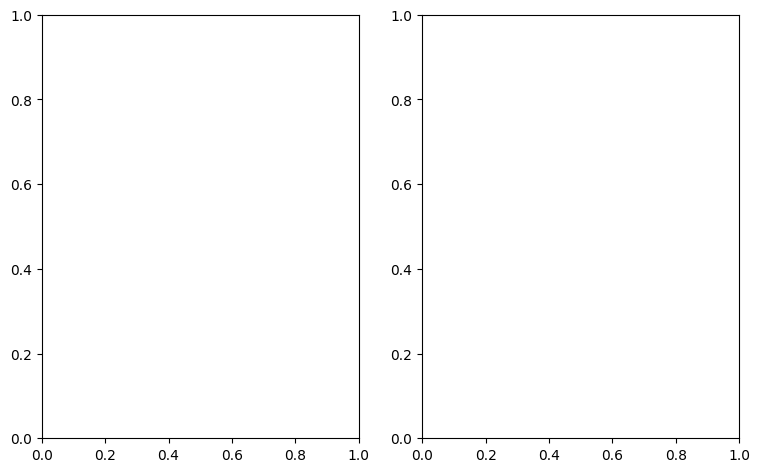

In [68]:
plot_shmf_redshifts(base_dir, suite_list, shmf_data)

0 0
All Objects Populated!
Saved!
1 5
All Objects Populated!
Saved!
2 10
All Objects Populated!
Saved!
3 15
All Objects Populated!
Saved!
4 20
All Objects Populated!
Saved!
5 25
All Objects Populated!
Saved!
6 30
All Objects Populated!
Saved!
7 35
All Objects Populated!
Saved!
8 40
All Objects Populated!
Saved!
9 45
All Objects Populated!
Saved!
10 50
All Objects Populated!
Saved!
11 55
All Objects Populated!
Saved!
12 60
All Objects Populated!
Saved!
13 65
All Objects Populated!
Saved!
14 70
All Objects Populated!
Saved!
15 75
All Objects Populated!
Saved!
16 80
All Objects Populated!
Saved!
17 85
All Objects Populated!
Saved!
18 90
All Objects Populated!
Saved!
19 95
All Objects Populated!
Saved!
20 100
All Objects Populated!
Saved!
21 105
All Objects Populated!
Saved!
22 110
All Objects Populated!
Saved!
23 115
All Objects Populated!
Saved!
24 120
All Objects Populated!
Saved!
25 125
All Objects Populated!
Saved!
26 130
All Objects Populated!
Saved!
27 135
All Objects Populated!
Sav

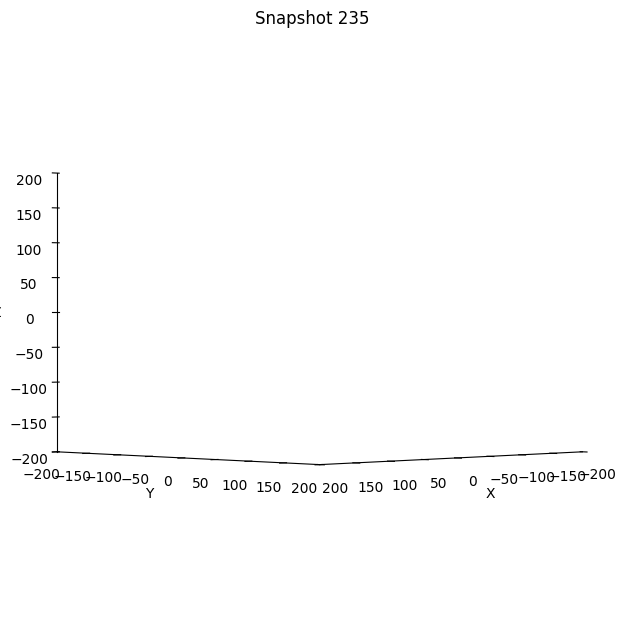

In [6]:
## GOAL: create a visualization that shows the behavior of subhalos in MWest over all snapshots
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation

base_dir = "C:/Users/steph/Symphony"
suite_list = ["MWest"]

image_directory = "mwest_visual/*.png"   # where to look for images to turn into a GIF, and where to save the GIF
output_directory = "mwest_visual"
output_gif_path = "mwest_visual.gif"

## create a 3-D plot that we can rotate and manipulate later to see what's going on
fig = plt.figure(figsize = (7.5, 7.5))
ax = fig.add_subplot(111, projection='3d')

u = np.linspace(0, 2 * np.pi, 40)   # defining these rotation linspaces for later
v = np.linspace(0, np.pi, 20)

sphere_x = np.outer(np.cos(u), np.sin(v))
sphere_y = np.outer(np.sin(u), np.sin(v))
sphere_z = np.outer(np.ones_like(u), np.cos(v))

## now we need to read the location and virial radius data for every subhalo and plot it
for suite_index, suite in enumerate(suite_list):
    n_hosts = symlib.n_hosts(suite)

    host = "Halo113"

    sim_dir = symlib.get_host_directory(base_dir, suite, host)
    scale_factors = symlib.scale_factors(sim_dir)
    scale_factors = scale_factors[scale_factors <= 1]

    snapshots = np.arange(0, 240, 5)
        
    h, hist = symlib.read_subhalos(sim_dir)

    for snap_index, snap in enumerate(snapshots):
        print(snap_index, snap)
        
        filename = f"Snapshot {(snap):.2f}.png"
        full_path = os.path.join(output_directory, filename)

        host_rvir = h["rvir"][0, snap]
        host_mvir = h["mvir"][0, snap]
        host_pos = h["x"][0, snap]

        sub_rvir = h["rvir"][1:, snap]
        sub_pos = h["x"][1:, snap]
        
        ok1 = h["ok"][1:, snap]
        ok_sub_pos = sub_pos[ok1]
        ok_sub_rvir = sub_rvir[ok1]

        sub_dist = np.sqrt(np.sum(ok_sub_pos**2, axis=1))

        host_cx, host_cy, host_cz = host_center = host_pos[0], host_pos[1], host_pos[2]
        host_x = host_rvir * np.outer(np.cos(u), np.sin(v)) + host_cx
        host_y = host_rvir * np.outer(np.sin(u), np.sin(v)) + host_cy
        host_z = host_rvir * np.outer(np.ones(np.size(u)), np.cos(v)) + host_cz
        ax.plot_surface(host_x, host_y, host_z, color = "tab:purple",
                       rcount = 20, ccount = 20, shade = False, antialiased=False)

        for index, subhalo in enumerate(ok_sub_rvir):
            if (sub_dist[index] < host_rvir - ok_sub_rvir[index]):
                sub_cx, sub_cy, sub_cz = ok_sub_pos[index][0], ok_sub_pos[index][1], ok_sub_pos[index][2]
                sub_x = ok_sub_rvir[index] * sphere_x + sub_cx
                sub_y = ok_sub_rvir[index] * sphere_y + sub_cy
                sub_z = ok_sub_rvir[index] * sphere_z + sub_cz
                ax.plot_surface(sub_x, sub_y, sub_z, color = "tab:green",
                               rcount = 20, ccount = 20, shade = False, antialiased=False)
                

            elif (sub_dist[index] > host_rvir + ok_sub_rvir[index]):
                sub_cx, sub_cy, sub_cz = ok_sub_pos[index][0], ok_sub_pos[index][1], ok_sub_pos[index][2]
                sub_x = ok_sub_rvir[index] * sphere_x + sub_cx
                sub_y = ok_sub_rvir[index] * sphere_y + sub_cy
                sub_z = ok_sub_rvir[index] * sphere_z + sub_cz
                ax.plot_surface(sub_x, sub_y, sub_z, color = "tab:red",
                               rcount = 20, ccount = 20, shade = False, antialiased=False)

        ax.view_init(elev = 0, azim = 45)
        ax.set_xlim(-200, 200)
        ax.set_ylim(-200, 200)
        ax.set_zlim(-200, 200)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.set_title(f"Snapshot {snap}")
    
        print("All Objects Populated!")
    
        plt.savefig(full_path, dpi = 80, facecolor = 'white')
        print("Saved!")

        ax.autoscale(enable=False)
        ax.grid(False)
        ax.xaxis.pane.set_visible(False)
        ax.yaxis.pane.set_visible(False)
        ax.zaxis.pane.set_visible(False)
        for coll in ax.collections[:]:
            coll.remove()

In [7]:
from matplotlib.animation import FuncAnimation, PillowWriter
from PIL import Image, ImageSequence
import glob
import re

pop_image_paths = sorted(glob.glob(image_directory), key=lambda x: int(re.search(r"(\d+)", x).group()))
 
# Load images 
images = []
for path in pop_image_paths:
    img = Image.open(path)
    images.append(img)

if images:
    images[0].save(output_gif_path, save_all=True, append_images=images[1:], duration = 100, loop=0)
    print(f"GIF created and saved at {output_gif_path}")
else:
    print("No images found in the specified directory.")

GIF created and saved at mwest_visual.gif


1 200
2 200
3 200
4 200
5 200
6 200
7 200
8 200
9 200
10 200
11 200
12 200
13 200
14 200
15 200
16 200
17 200
18 200
19 200
20 200
21 200
22 200
23 200
24 200
25 200
26 200
27 200
28 200
29 200
30 200
31 200
32 200
33 200
34 200
35 200
36 200
37 200
38 200
39 200
40 200
41 200
42 200
43 200
44 200
45 200
46 200
47 200
48 200
49 200
50 200
51 200
52 200
53 200
54 200
55 200
56 200
57 200
58 200
59 200
60 200
61 200
62 200
63 200
64 200
65 200
66 200
67 200
68 200
69 200
70 200
71 200
72 200
73 200
74 200
75 200
76 200
77 200
78 200
79 200
80 200
81 200
82 200
83 200
84 200
85 200
86 200
87 200
88 200
89 200
90 200
91 200
92 200
93 200
94 200
95 200
96 200
97 200
98 200
99 200
100 200
101 200
102 200
103 200
104 200
105 200
106 200
107 200
108 200
109 200
110 200
111 200
112 200
113 200
114 200
115 200
116 200
117 200
118 200
119 200
120 200
121 200
122 200
123 200
124 200
125 200
126 200
127 200
128 200
129 200
130 200
131 200
132 200
133 200
134 200
135 200
136 200
137 200
138 200
139 

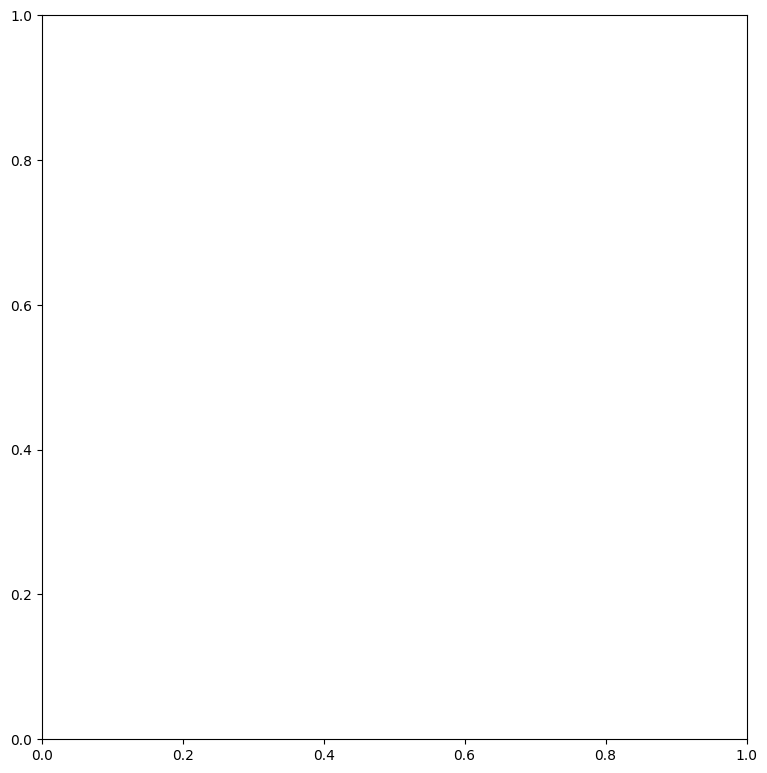

In [3]:
# generating subhalo location and mass vs time gifs!

from matplotlib.animation import FuncAnimation, PillowWriter
from PIL import Image, ImageSequence
import glob
import re

base_dir = "C:/Users/steph/Symphony"
suite_list = ["SymphonyCluster"]
image_directory = "subhalo_gif/*.png"
output_gif_path = "subhalo_animation.gif"

fig, ax = plt.subplots(ncols = 1, nrows = 1, figsize = (8, 8))

for suite_index, suite_name in enumerate(suite_list):
    n_hosts = symlib.n_hosts(suite_name)
    
    for i_host in range(1):
        sim_dir = symlib.get_host_directory(base_dir, suite_name, i_host)
        scale_factors = symlib.scale_factors(sim_dir)
        h, hist = symlib.read_subhalos(sim_dir)

        for snap_index, snap in enumerate(scale_factors):
            host = h[0, snap_index]
            symlib.plot_circle(ax, host["x"][0], host["x"][1], host["rvir"], c = "tab:red")
            
            z0_radius = 100
        
            for i in range(1, len(h)):
                sub = h[i, snap_index]
                if sub["ok"]:
                    symlib.plot_circle(ax, sub['x'][0], sub['x'][1], sub['rvir'], c = "tab:blue", lw = 1.5)

            ax.set_xlim(-7*host["rvir"], 7*host["rvir"])
            ax.set_ylim(-7*host["rvir"], 7*host["rvir"])                            
            #ax.set_xlim(-3000, 3000)
            #ax.set_ylim(-3000, 3000)
            
            ax.set_title(f'a = {(snap):2f}')
            plt.tight_layout()
            
            output_directory = "subhalo_gif"
            filename = f"subhalo_image_{snap_index}.png"
            
            if not os.path.exists(output_directory):
                os.makedirs(output_directory)
                
            full_path = os.path.join(output_directory, filename)
            plt.savefig(full_path, dpi = 100, facecolor = 'white')

            if snap_index < len(scale_factors):
                print(snap_index + 1, len(scale_factors))
                ax.clear()

In [4]:
from matplotlib.animation import FuncAnimation, PillowWriter
from PIL import Image, ImageSequence
import glob
import re

image_directory = "subhalo_gif/*.png"
output_gif_path = "subhalo_animation.gif"

image_paths = glob.glob(image_directory)
image_paths = sorted(glob.glob(image_directory), key=lambda x: int(re.search(r"(\d+)", x).group()))
 
# Load images 
images = []
for path in image_paths:
    img = Image.open(path)
    images.append(img)

if images:
    images[0].save(output_gif_path, save_all=True, append_images=images[1:], duration = 75, loop=0)
    print(f"GIF created and saved at {output_gif_path}")
else:
    print("No images found in the specified directory.")

GIF created and saved at subhalo_animation.gif
